# Comparing Pathfinder internal layers to snow profile

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.append(os.path.abspath('../Pathfinder'))

from helper_functions import *
from radar_functions import *
from pathfinder import *
from attach_grounddata import *
from add_dataflashlog import *
from clicki_tool import *

%matplotlib inline

In [2]:
campaignID = '2024_SIOS'

RADARs = {}
for datasetID in ['26_04_2024_3', '26_04_2024_4', '26_04_2024_5']:
    RADAR = load_RADAR(radar_type='UWiBaSS',
                    datasetID=datasetID,
                    campaignID=campaignID,
                    yaml_file="./campaigns.yaml"
                    )
    zone_number = utm.latlon_to_zone_number(np.nanmedian(RADAR.GPS_Lat), np.nanmedian(RADAR.GPS_Lng))
    RADAR.UTM_zone = zone_number
    UTM_transformer = Transformer.from_crs(4326, CRS.from_proj4(f"+proj=utm +zone={RADAR.UTM_zone} +ellps=WGS84 +datum=WGS84 +units=m +type=crs"), always_xy=True)
    if 'rx_rpca_T' in RADAR.__dict__:
        RADAR.rx_rpca = RADAR.rx_rpca_T
        
    RADAR = add_radar_footprints(RADAR)

    RADAR, df_MP, df_SP, dict_SP = add_insitu(RADAR, UTM_transformer)

    RADARs[datasetID] = RADAR
    
    

Dataset 26_04_2024_3 from campaign 2024_SIOS is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/26_04_2024_3/uwibass_object.pkl
Co-locating in-situ data to radar footprints..
Dataset 26_04_2024_4 from campaign 2024_SIOS is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/26_04_2024_4/uwibass_object.pkl
Co-locating in-situ data to radar footprints..
Dataset 26_04_2024_5 from campaign 2024_SIOS is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/26_04_2024_5/uwibass_object.pkl
Co-locating in-situ data to radar footprints..


In [3]:
df = pd.read_csv('../Data/svalbard_lufthavn_weather.csv', sep=';',on_bad_lines='skip')
df['Time(norwegian mean time)'] = pd.to_datetime(df['Time(norwegian mean time)'], format='%d.%m.%Y %H:%M')
df['Precipitation (1 h)'] = df['Precipitation (1 h)'].replace('-', '0', regex=True).astype(float)
df_lufthavn = df[df['Name'] == 'Svalbard Lufthavn']

In [4]:
# Example: resample each dataset's snow depth to regular spacing
resampled_snow_depths = {}

for key, uwi in RADARs.items():
    
    dist = np.array(uwi.dist)
    regular_spacing = np.mean(np.diff(dist))  # meters
    
    snow_depth = np.array(uwi.PF_snow_depth)
    mask = np.isfinite(dist) & np.isfinite(snow_depth)
    dist = dist[mask]
    snow_depth = snow_depth[mask]

    if len(dist) > 1:
        dist_regular = np.arange(dist.min(), dist.max(), regular_spacing)
        interp_func = interp1d(dist, snow_depth, kind='linear', fill_value='extrapolate')
        resampled_snow_depths[key] = interp_func(dist_regular)
    else:
        resampled_snow_depths[key] = np.array([])  # Not enough points to interpolate

In [5]:
all_GPS_Statii = [uwi.GPS_Status for uwi in RADARs.values()]
all_GPS_Statii = np.concatenate(all_GPS_Statii)

all_idx_from_top = [uwi.PF_internal_layers['idx_from_top'] for uwi in RADARs.values()]
all_idx_from_top = np.concatenate(all_idx_from_top)

all_idx_from_bottom = [uwi.PF_internal_layers['idx_from_bottom'] for uwi in RADARs.values()]
all_idx_from_bottom = np.concatenate(all_idx_from_bottom)

# all_value_at_internal  = [uwi.rx_rpca[np.array(uwi.PF_internal_layers['idx_from_top']) + np.array(uwi.PF_top_interface), range(len(uwi.PF_internal_layers['idx_from_top']))] for uwi in data_dict.values()]

all_internal_SNR = [uwi.PF_internal_layers['SNR'] for uwi in RADARs.values()]
all_internal_SNR = np.concatenate(all_internal_SNR)

all_internal_UTM_x = []
all_internal_UTM_y = []

all_N_layers = []
all_value_at_internal  = []

for uwi in RADARs.values():
    internal_x = [list(zip(*p))[1] for p in uwi.PF_internal_layers['paths']] 
    internal_y = [list(zip(*p))[0] for p in uwi.PF_internal_layers['paths']]
    internal_x = np.concatenate(internal_x)
    internal_y = np.concatenate(internal_y)
    try:
        all_value_at_internal.append(uwi.rx_rpca[internal_y, internal_x])
    except:
        all_value_at_internal.append(uwi.rx_rpca_T[internal_y, internal_x])
    
    N_layers = [len(internal_y[internal_x == x]) - 1 for x in internal_x]
    all_N_layers.append(N_layers)
    all_internal_UTM_x.append(uwi.log_UTM_x[internal_x])
    all_internal_UTM_y.append(uwi.log_UTM_y[internal_x])

all_value_at_internal = np.concatenate(all_value_at_internal)
all_N_layers = np.concatenate(all_N_layers)
all_internal_UTM_x = np.concatenate(all_internal_UTM_x)
all_internal_UTM_y = np.concatenate(all_internal_UTM_y)

all_snow_depths_indices = [uwi.PF_bottom_interface - uwi.PF_top_interface for uwi in RADARs.values()]
all_snow_depths_indices = np.concatenate(all_snow_depths_indices)

all_snow_depths_resampled = [sd for sd in resampled_snow_depths.values()]
all_snow_depths_resampled = np.concatenate(all_snow_depths_resampled)

all_snow_depths = [uwi.PF_snow_depth for uwi in RADARs.values()]
all_snow_depths = np.concatenate(all_snow_depths)

all_UTM_x = [uwi.log_UTM_x for uwi in RADARs.values()]
all_UTM_y = [uwi.log_UTM_y for uwi in RADARs.values()]
all_UTM_y = np.concatenate(all_UTM_y)
all_UTM_x = np.concatenate(all_UTM_x)

all_lon = [uwi.GPS_Lng for uwi in RADARs.values()]
all_lat = [uwi.GPS_Lat for uwi in RADARs.values()]
all_lat = np.concatenate(all_lat)
all_lon = np.concatenate(all_lon)

In [6]:
def plot_snowprofile(dicti, ax, plot_type='density', align='left', mode='relative', coordinatesystem='uwibass'):
    
    if plot_type in dicti['profiles'][0].keys():

        var = dicti['profiles'][0][plot_type]
        layers = var['elements'][0]['layers']
        values = [layer['value'] if 'value' in layer.keys() else np.nan for layer in layers]

        if coordinatesystem == 'uwibass':
            var_uwi = dicti['profiles'][0]['RADAR_range_bins']
            layers_uwi = var_uwi['elements'][0]['layers']
            bottoms = [layer['bottom'] for layer in layers_uwi]
            tops = [layer['top'] for layer in layers_uwi]
            
        elif coordinatesystem == 'snowprofile':
            bottoms = [layer['bottom'] for layer in layers]
            tops = [layer['top'] for layer in layers]
            
        else: 
            raise ValueError("coordinatesystem must be either 'uwibass' or 'snowprofile'.")

        # Calculate bar positions and heights
        if mode == 'relative':
            bar_bottoms = bottoms / np.max(bottoms)
            bar_heights = [(top - bottom) / np.max(bottoms) for bottom, top in zip(bottoms, tops)]
            
        elif mode == 'absolute':
            bar_bottoms = bottoms
            bar_heights = [top - bottom for bottom, top in zip(bottoms, tops)]
            
        else:
            raise ValueError("Mode must be either 'relative' or 'absolute'.")

        
        if plot_type == 'hardness':
            # Convert hardness values to indices and then to N-values
            hardness_map_indices = {
                1: 'F',
                2: '4F',
                3: '1F',
                4: 'P',
                5: 'K',
                6: 'I'
            }
            hardness_map_N = {
                1: 10,
                1.5 : 55,
                2: 100,
                3: 250,
                3.5: 375,
                4: 500,
                4.5: 750,
                5: 1000,
                6: 1500
            }
            # values_indices = [hardness_map_indices.get(value, np.nan) for value in values]
            values = [hardness_map_N.get(value, np.nan) for value in values]
        
        if plot_type == 'refractive_index':
            values[-1] = np.nan
            values = list(reversed(values))

            values =  np.sqrt(values)
        if align == 'left':
            ax.barh(
                y=bar_bottoms,
                width=values,
                height=bar_heights,
                left=None,
                color='skyblue',
                align='edge',
                edgecolor='deepskyblue',
                alpha=.5
            )
            ax.set_ylabel('Height [cm]')
            # ax[0].set_xlabel('Density [kg/m³]')

            # Set y-ticks at both top and bottom of each layer
            # y_tick_positions = []
            # y_tick_labels = []
            # for layer in layers:
            #     # y_tick_positions.extend([layer['bottom'], layer['top']])
            #     # y_tick_labels.extend([f"{layer['bottom']:.0f}", f"{layer['top']:.0f}"])
            #     y_tick_positions.extend([layer['bottom']])
            #     y_tick_labels.extend([f"{layer['bottom']:.0f}"])
            # ax.set_yticks(y_tick_positions)
            # ax.set_yticklabels(y_tick_labels)
            ax.set_xlim(0, max(values) + 350)
            ax.set_xticks(np.linspace(0, (( max(values) // 25) + 1) * 25, 6))
            ax.set_xlabel('Density [kg/m³]', loc='left', color='deepskyblue')
            ax.set_ylim(ymin=0)

        elif align == 'right':
            ax2 = ax.twiny()
            ax2.invert_xaxis()
            ax2.set_zorder(0)


            ax2.barh(
                y=bar_bottoms,
                width=values,
                height=bar_heights,
                left=None,
                color='limegreen',
                align='edge',
                edgecolor='green',
                alpha=.35
            )
            # ax2.set_ylabel('Height [cm]')
            
            # y_tick_positions = []
            # y_tick_labels = []
            # for layer in layers:
                # y_tick_positions.extend([layer['bottom'], layer['top']])
                # y_tick_labels.extend([f"{layer['bottom']:.0f}", f"{layer['top']:.0f}"])
                # y_tick_positions.extend([layer['top']])
                # y_tick_labels.extend([f"{layer['top']:.0f}"])
            # ax2.set_yticks(bar_bottoms)
            # ax2.yaxis.set_ticks_position('right')
            # ax2.set_yticklabels(y_tick_labels)
            ax2.set_xlim( np.nanmax(values) + 0.3 * np.nanmax(values), np.nanmin(values) - 0.2 * np.nanmin(values))
            ax2.set_xlabel('Refractive index  $\\eta_{ds}$ ', color='mediumseagreen', loc='right')
            ax2.tick_params(axis='x', colors='mediumseagreen')
            ax2.spines['top'].set_color('mediumseagreen')
            ax2.spines['bottom'].set_color('white')
            
            ax2.spines.top.set_position(("axes", 1.025))
            
            # ax2.spines['right'].set_color('white')

            # ax2.set_xticks(list(hardness_map_N.values()))
            # ax2.set_xticklabels(list(hardness_map_N.keys()))


    else:
        warnings.warn(f"Plot type '{plot_type}' not found in the provided dictionary.", UserWarning)
        if plot_type == 'density':
            ax.set_xticks([])
        elif plot_type == 'hardness':
            ax2.set_xticks([])
        return

(np.float64(0.30579143),
 np.float64(0.38433904),
 np.float64(0.6974144),
 np.float64(1.0))

Text(-0.2, 1.1, 'b)')

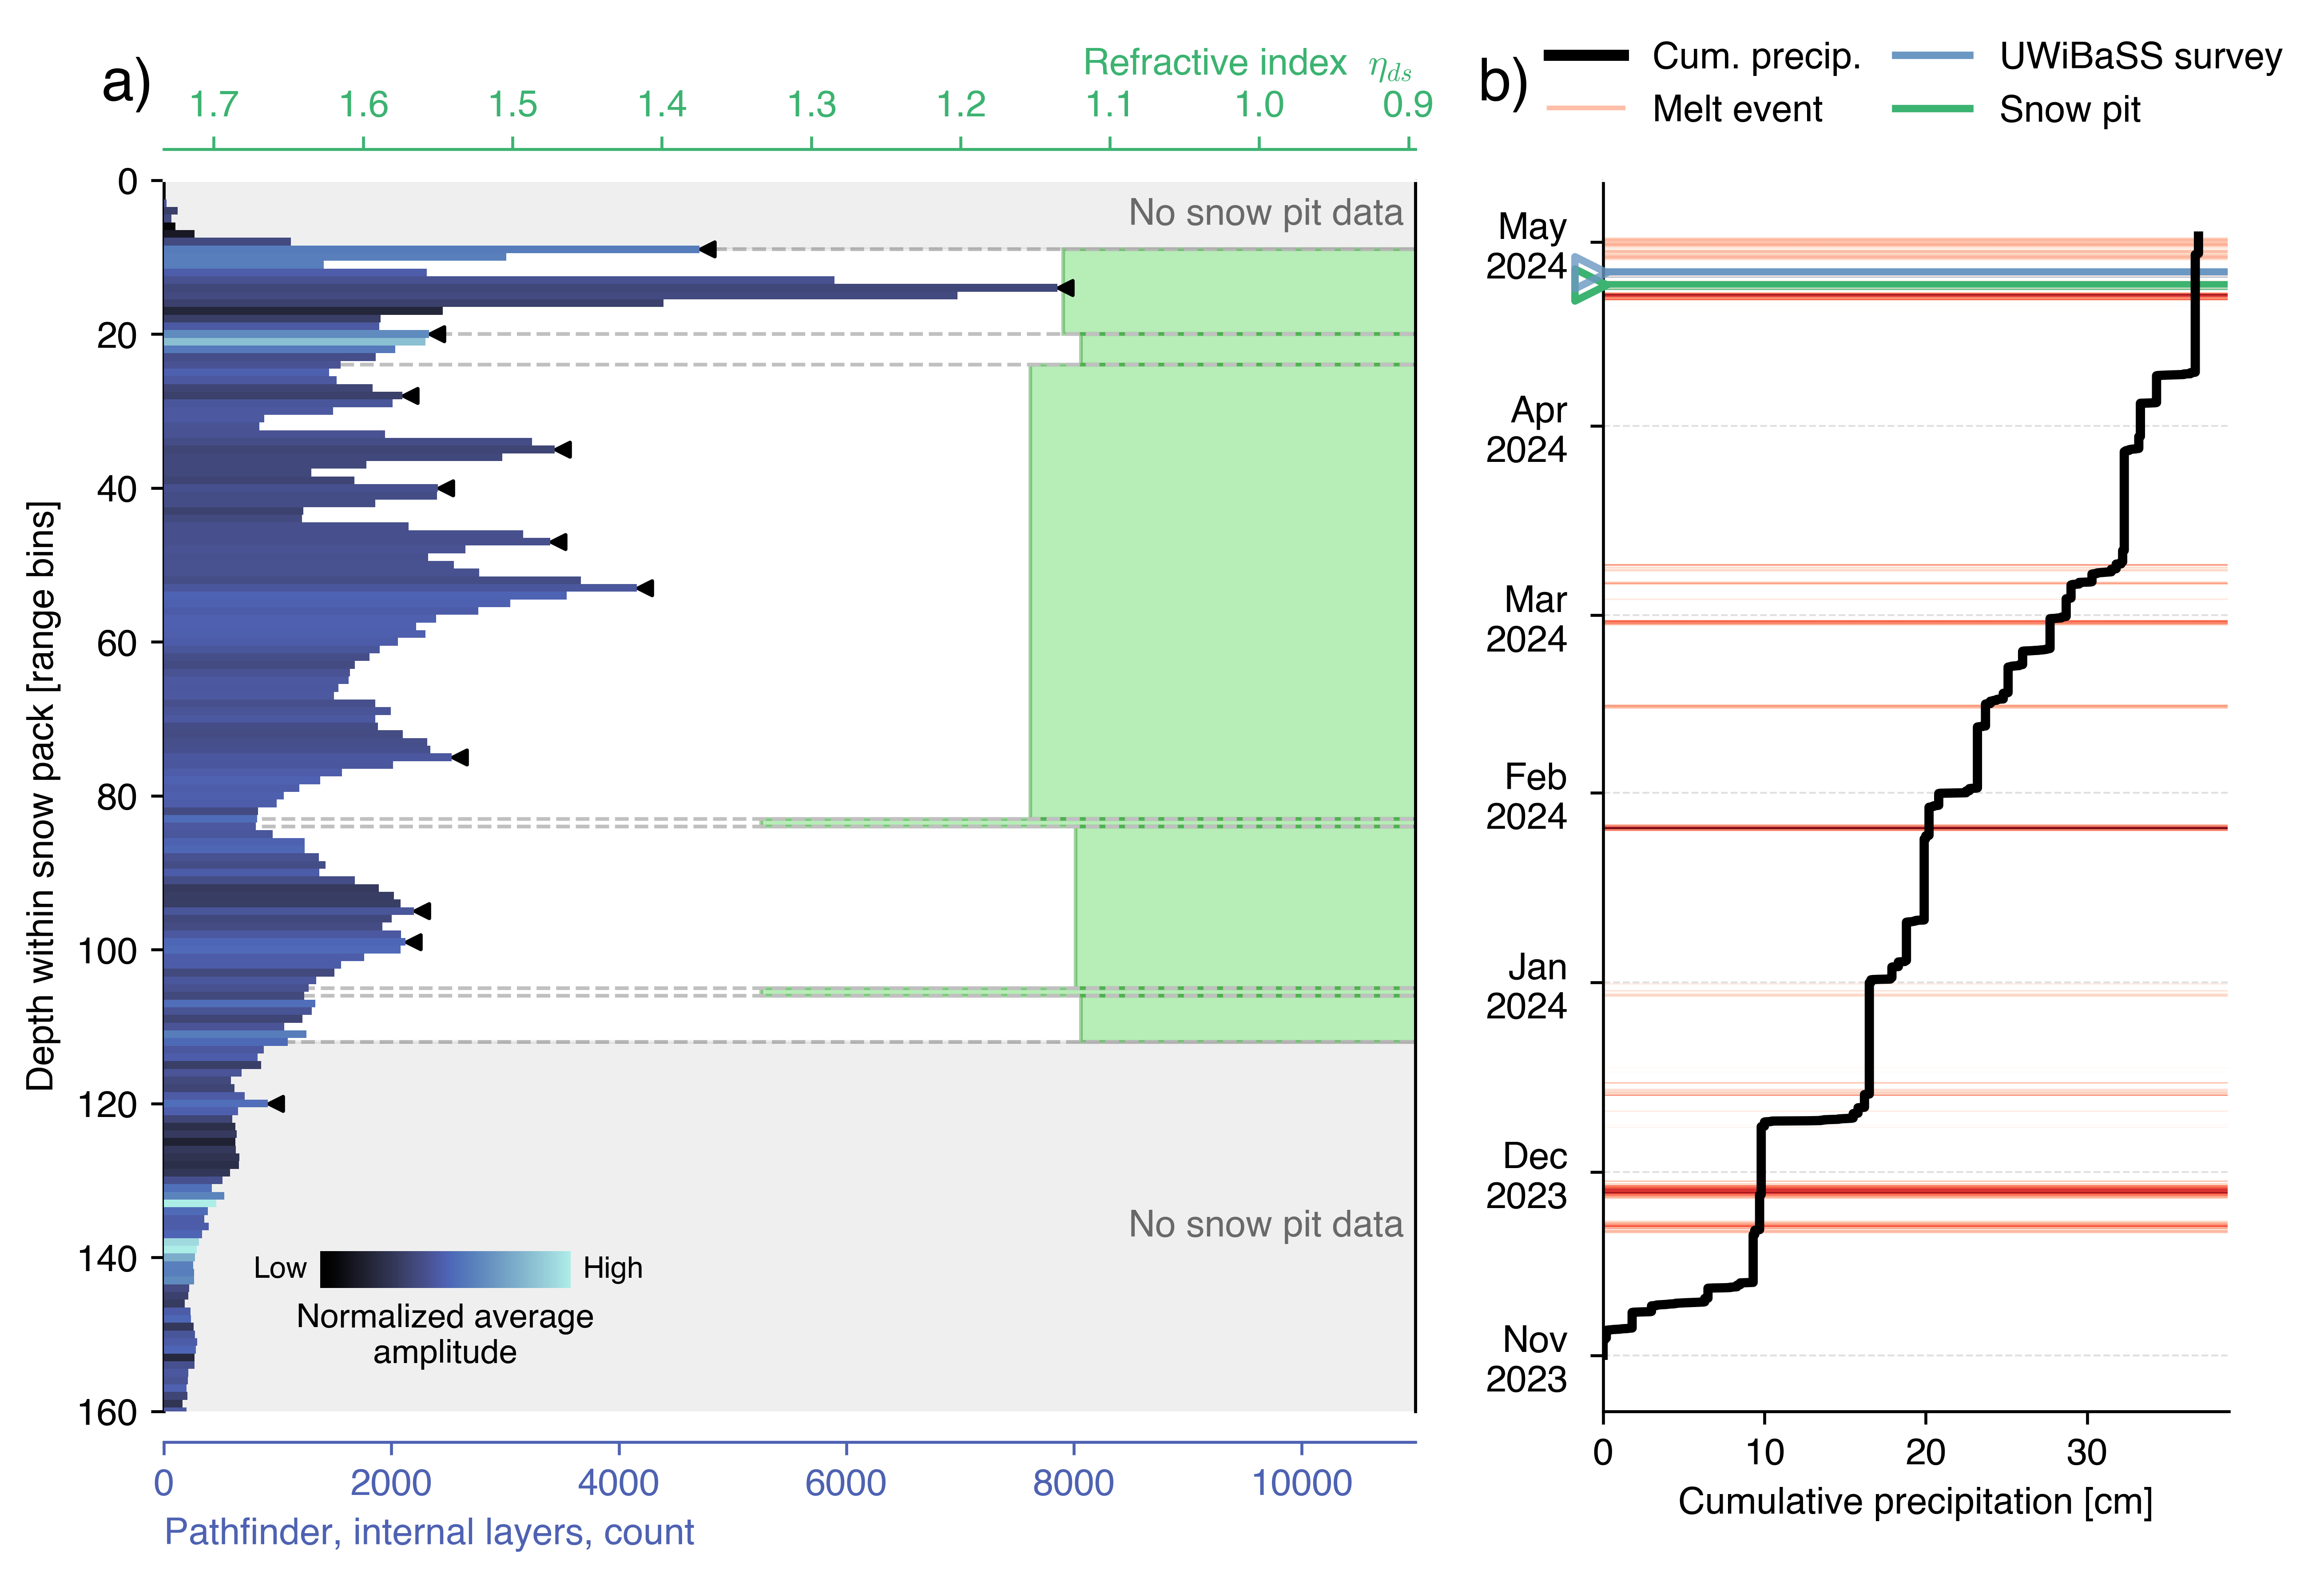

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6), width_ratios=[2, 1], dpi=600)
fig.subplots_adjust(wspace=0.2)  # Add horizontal space (pad) between panels
ax[0].set_ylim(160, 0)
ax[0].set_zorder(1)
ax[0].patch.set_visible(False) # hide the 'canvas'

plot_snowprofile(dict_SP, ax[0], plot_type='refractive_index', align='right', mode='absolute', coordinatesystem='uwibass')


for i in RADARs['26_04_2024_5'].SP_bottom_layers:
    ax[0].axhline(i,
               color='silver',
               ls='--', lw=1,
               zorder=-1
               )
    
counts, bin_edges = np.histogram(all_idx_from_top, bins=np.arange(0, np.max(all_snow_depths_indices) + 1, 1))

bin_indices = np.digitize(all_idx_from_top, bin_edges) - 1

sums = np.bincount(bin_indices, weights=all_value_at_internal, minlength=len(counts))
counts = np.bincount(bin_indices, minlength=len(counts))

avg_values = sums / counts
avg_values[counts == 0] = np.nan  # avoid division by zero

peaks, _ = find_peaks(counts, prominence=200)

my_cmap = cmr.sapphire
norm = Normalize(vmin=np.nanquantile(avg_values, 0.02), vmax=np.nanquantile(avg_values, 0.98))

ax[0].scatter(counts[peaks] + 70, peaks, marker='<', color='black', s=15, label='Dominant peaks')
# ax[0].barh(bin_edges[:-1], counts, height=1, color='dodgerblue', alpha=0.5, zorder=10, edgecolor='deepskyblue', lw=.1)
ax[0].barh(bin_edges[:-1], counts, height=1, color=my_cmap(norm(avg_values)), zorder=10, edgecolor='none')

ax[0].spines['top'].set_color('white')
ax[0].spines['bottom'].set_color(my_cmap(.5))

ax[0].axhspan(0, RADARs['26_04_2024_5'].SP_bottom_layers[0], color='dimgrey', zorder=0, alpha=0.1)
ax[0].text(11000-100,RADARs['26_04_2024_5'].SP_bottom_layers[0]/2 , 'No snow pit data', ha='right', va='center', color='dimgrey', fontsize=10)
ax[0].text(11000-100,(RADARs['26_04_2024_5'].SP_bottom_layers[-1]+160)/2, 'No snow pit data', ha='right', va='center', color='dimgrey', fontsize=10)

ax[0].axhspan(RADARs['26_04_2024_5'].SP_bottom_layers[-1],1000, color='dimgrey', zorder=0, alpha=0.1)

ax[0].xaxis.label.set_color(my_cmap(.5))
ax[0].tick_params(axis='x', colors=my_cmap(.5))
ax[0].set_ylabel('Depth within snow pack [range bins]')

ax[0].set_xlabel('Pathfinder, internal layers, count', loc='left')
ax[0].set_xlim(0, 11000)


ax[0].spines.bottom.set_position(("axes", -.025))

# ax[0].legend(frameon=True, loc='lower left')

ax0_inset = ax[0].inset_axes([0.125, 0.1, 0.2, 0.03], zorder=2)  # [left, bottom, width, height]
cbar = fig.colorbar(mpl.cm.ScalarMappable(cmap=my_cmap), cax=ax0_inset, orientation='horizontal')
cbar.set_label('Normalized average\namplitude', fontsize=9)
cbar.outline.set_visible(False)
cbar.ax.xaxis.set_ticks([])
cbar.ax.text(-.05, .5, "Low", ha='right', va='center', transform=cbar.ax.transAxes, size=8)
cbar.ax.text(1.05, .5, "High", ha='left', va='center', transform=cbar.ax.transAxes, size=8)

ax[1].plot(np.cumsum(df_lufthavn['Precipitation (1 h)']), df_lufthavn['Time(norwegian mean time)'], lw=2.5, color='black', zorder=10)

ax[1].scatter(-.75, pd.to_datetime('2024-04-26 00:00'), fc='none', ec=my_cmap(0.7), lw=2, s=75, marker='>', zorder=50, clip_on=False, alpha=.8)
ax[1].scatter(-.75, pd.to_datetime('2024-04-24 00:00'), fc='none', ec='mediumseagreen', lw=2, s=75, marker='>', zorder=20, clip_on=False)

ax[1].axhline(pd.to_datetime('2024-04-26 00:00'), color=my_cmap(0.7), lw=2.5, label='UWiBaSS survey')
ax[1].axhline(pd.to_datetime('2024-04-24 00:00'), color='mediumseagreen', lw=2.5, label='Snow pit')
ax[1].grid(axis='y', color='lightgray', linestyle='--', lw=0.5, alpha=0.7)



temp_cmap = mpl.colormaps['Reds']
temp_norm = mpl.colors.Normalize(vmin=0, vmax=df_lufthavn['Air temperature'].max())

for i in df_lufthavn.loc[df_lufthavn['Air temperature'] > 0].index:
    color = temp_cmap(temp_norm(df_lufthavn['Air temperature'][i]))
    ax[1].axhline(df_lufthavn['Time(norwegian mean time)'][i], color=color, lw=0.1, alpha=1, label='Melt event' if i == df_lufthavn.loc[df_lufthavn['Air temperature'] > 0].index[0] else None)

custom_legend_elements = [
    Line2D([0], [0], color='black', lw=3, label='Cum. precip.'),
    Line2D([0], [0], color='coral', lw=1.25, alpha=.5, label='Melt event'),
    Line2D([0], [0], color=my_cmap(0.7), lw=2, label='UWiBaSS survey'),
    Line2D([0], [0], color='mediumseagreen', lw=2, label='Snow pit')
]
ax[1].legend(handles=custom_legend_elements, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.14), ncol=2, columnspacing=0.9)
ax[1].spines['right'].set_color('white')
ax[1].spines['top'].set_color('white')

ax[1].set_xlabel('Cumulative precipitation [cm]', color='black')


ax[1].set_xlim(left=0)

import matplotlib.dates as mdates
ax[1].yaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

for tick in ax[1].get_yaxis().get_major_ticks():
    tick.set_pad(6)

ax[0].text(-.05, 1.1, 'a)', transform=ax[0].transAxes, fontsize=16, fontweight='bold', va='top', ha='left', color='black')
ax[1].text(-.2, 1.1, 'b)', transform=ax[1].transAxes, fontsize=16, fontweight='bold', va='top', ha='left', color='black')

# ax[1].plot(np.cumsum(df_lufthavn['Precipitation (1 h)']), df_lufthavn['Time(norwegian mean time)'], lw=3, color='black', label='Cumulative precipitation')
# ax[1].axhline(pd.to_datetime('2024-04-26 00:00'), color='skyblue', lw=2, label='UWiBaSS survey')
# ax[1].axhline(pd.to_datetime('2024-04-24 00:00'), color='goldenrod', lw=2, label='Snow pit')
# ax[1].grid(axis='y', color='lightgray', linestyle='--', lw=0.5, alpha=0.7)
# for i in df_lufthavn.loc[df_lufthavn['Air temperature'] > 0].index:
#     ax[1].axhline(df_lufthavn['Time(norwegian mean time)'][i], color='coral', lw=0.1, alpha=.2, label='Melt event' if i == df_lufthavn.loc[df_lufthavn['Air temperature'] > 0].index[0] else None)

# custom_legend_elements = [
#     Line2D([0], [0], color='black', lw=3, label='Cum. precip.'),
#     Line2D([0], [0], color='coral', lw=1.25, alpha=.5, label='Melt event'),
#     Line2D([0], [0], color='skyblue', lw=2, label='UWiBaSS survey'),
#     Line2D([0], [0], color='goldenrod', lw=2, label='Snow pit')
# ]
# ax[1].legend(handles=custom_legend_elements, frameon=False, loc='upper center', bbox_to_anchor=(0.6, 1.15), ncol=2)
# ax[1].spines['right'].set_color('white')
# ax[1].spines['top'].set_color('white')

# ax[1].set_xlabel('Cumulative precipitation [cm]', color='black')


# 
# ax.set_title('Svalbard Lufthavn data', x=0, ha='left')


In [21]:
fig.savefig('./export/fig05.pdf', dpi=600, bbox_inches='tight')
